### **Brazilian E-Commerce**

In [ ]:
# Importando  Blibliotecas

# Manipulação de Dados
import pandas as pd
import numpy as np

# Visualização de Dados
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
# Importando bases

dim_cliente = pd.read_csv( '/content/dim_cliente.csv')
localizacao = pd.read_csv( '/content/localizacao.csv')
fat_pedidos_itens = pd.read_csv( '/content/fat_pedidos_itens.csv')
fat_pagamentos = pd.read_csv( '/content/fat_pagamentos.csv')
dim_reviews = pd.read_csv( '/content/dim_reviews.csv')
fat_pedidos = pd.read_csv( '/content/fat_pedidos.csv')
dim_produto = pd.read_csv( '/content/dim_produto.csv')
dim_vendedor = pd.read_csv( '/content/dim_vendedor.csv')
dim_categoria = pd.read_csv( '/content/dim_categoria.csv')


In [ ]:
# Criando uma tabela calendario para auxiliar na criação de graficos e relacionametnos futuros.
# Intervalo do df
calendario = pd.DataFrame({
    'data': pd.date_range(start='2016-10-01', end='2018-09-30', freq='D')
})

# Criação das colunas
calendario['dia_da_semana'] = calendario['data'].dt.day_name()
calendario['mes'] = calendario['data'].dt.month
calendario['ano'] = calendario['data'].dt.year
calendario['trimestre'] = calendario['data'].dt.quarter
calendario['semestre'] = calendario['mes'].apply(lambda x: 1 if x <= 6 else 2)
calendario['mes_ano'] = calendario['data'].dt.to_period('M')


# Visualizar
print(calendario.head())

calendario.to_csv('calendario.csv', index=False)

        data dia_da_semana  mes   ano  trimestre  semestre  mes_ano
0 2016-10-01      Saturday   10  2016          4         2  2016-10
1 2016-10-02        Sunday   10  2016          4         2  2016-10
2 2016-10-03        Monday   10  2016          4         2  2016-10
3 2016-10-04       Tuesday   10  2016          4         2  2016-10
4 2016-10-05     Wednesday   10  2016          4         2  2016-10


In [ ]:
# Verificando estrutura de cada tabela
#dim_cliente.head()
#localizacao.head()
#fat_pedidos_itens.head()
#fat_pagamentos.head()
#dim_reviews.head()
#fat_pedidos.head()
#dim_produto.head()
#dim_vendedor.head()
#fat_pagamentos.head()

In [ ]:
# Checando colunas especificas para não termos registros divergentes para o mesmo item ("audio" e "Audio") por exemplo
fat_pagamentos['payment_type'].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [ ]:
# Renomeando colunas de todas as bases para facilitar possiveis tratamentos futuros na hora de mostrar os dados para o cliente final
dim_cliente = dim_cliente.rename(columns= {'customer_id': 'id_cliente', 'customer_unique_id': 'id_cliente_unico','customer_zip_code_prefix':'raiz_cep' , 'customer_city':'cidade_cliente','customer_state':'estado_cliente'})

localizacao = localizacao.rename(columns= {'geolocation_zip_code_prefix': 'raiz_cep', 'geolocation_city': 'cidade','geolocation_state':'estado' })

fat_pedidos_itens = fat_pedidos_itens.rename(columns= {'order_id': 'id_pedido','order_item_id':'id_pedido_item', 'product_id':'id_produto','seller_id':'id_vendedor','shipping_limit_date':'data_envio_limite','price':'preco','freight_value':'valor_frete' })

fat_pagamentos = fat_pagamentos.rename(columns= {'order_id': 'id_pedido','payment_sequential':'pagamento_seq', 'payment_type':'forma_pagamento','payment_installments':'parcela','payment_value':'valor_pago' })

dim_reviews = dim_reviews.rename(columns= {'review_id': 'id_avaliacao','order_id':'pedido_id','review_score':'nota' })

fat_pedidos = fat_pedidos.rename(columns= {'order_id': 'id_pedido','customer_id':'id_cliente','order_status':'status', 'order_purchase_timestamp':'data_compra', 'order_approved_at':'data_aprovacao', 'order_delivered_carrier_date':'data_entrega_transportadora', 'order_delivered_customer_date':'data_entrega_cliente', 'order_estimated_delivery_date': 'data_entrega_estimada'})

dim_produto = dim_produto.rename(columns= {'product_id': 'id_produto','product_category_name':'categoria_produto'})

dim_vendedor = dim_vendedor.rename(columns= {'seller_id': 'id_vendedor','seller_zip_code_prefix':'raiz_cep_vendedor', 'seller_city':'cidade_vendedor', 'seller_state':'estado_vendedor'})

In [ ]:
fat_pedidos_itens.head()
#dim_reviews.info()

,id_pedido,id_pedido_item,id_produto,id_vendedor,data_envio_limite,preco,valor_frete
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
# Tratando conteudo de algumas colunas para melhor construção dos gráficos
fat_pedidos['status'] = fat_pedidos['status'].replace({
    'delivered': 'entregue',
    'invoiced': 'faturado',
    'shipped': 'enviado',
    'processing': 'processando',
    'unavailable' :'indisponivel',
    'canceled': 'cancelado',
    'created': 'criado',
    'approved': 'aprovado'
})

In [ ]:
# Transformando em data as colunas de data de cada tabela
# Utilizando normalize para zerar os horários e facilitar o merge entre as tabelas

fat_pedidos_itens['data_envio_limite'] = pd.to_datetime(fat_pedidos_itens['data_envio_limite'])
dim_reviews['review_creation_date'] = pd.to_datetime(dim_reviews['review_creation_date'])
dim_reviews['review_answer_timestamp'] = pd.to_datetime(dim_reviews['review_answer_timestamp'])
fat_pedidos['data_compra'] = pd.to_datetime(fat_pedidos['data_compra']).dt.normalize()
fat_pedidos['data_aprovacao'] = pd.to_datetime(fat_pedidos['data_aprovacao'])
fat_pedidos['data_entrega_transportadora'] = pd.to_datetime(fat_pedidos['data_entrega_transportadora'])
fat_pedidos['data_entrega_cliente'] = pd.to_datetime(fat_pedidos['data_entrega_cliente'])
fat_pedidos['data_entrega_estimada'] = pd.to_datetime(fat_pedidos['data_entrega_estimada'])
calendario['data'] = pd.to_datetime(calendario['data']).dt.normalize()


In [ ]:
# Aqui estamos criando uma coluna chamada STATUS_ENTREGA, para analisar futuramente se entregamos dentro do prazo e se isso impacta na nota/review
fat_pedidos['status_entrega'] = np.where(
    fat_pedidos['status'] == 'entregue',

    np.where(
        fat_pedidos['data_entrega_cliente'].dt.date < fat_pedidos['data_entrega_estimada'].dt.date,
        'antecipada',
        np.where(
            fat_pedidos['data_entrega_cliente'].dt.date == fat_pedidos['data_entrega_estimada'].dt.date,
            'ok',
            'atraso'
        )
    ),

    None
)

### Relacionamentos entre Tabelas

Agora vou criar o relacionamento entre ***calendario*** e ***fat_pedidos***

In [ ]:
# Agrupando o valor total de cada pedido (Preco e Frete)

fat_pedidos_itens_valor_pedido = fat_pedidos_itens.groupby('id_pedido')[['preco', 'valor_frete']].sum().reset_index()
fat_pedidos_itens_valor_pedido.head()

# Após esse merge, temos o valor total de cada pedido (id_pedido) e o seu respectivo frete

,id_pedido,preco,valor_frete
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14


In [ ]:
fat_pedidos_valor = fat_pedidos.merge(fat_pedidos_itens_valor_pedido, on='id_pedido', how='left')

# Esse passo é para termos na fat_pedidos que agora é fat_pedidos_valor o valor e frete junto das datas relacionadas ao pedido

In [ ]:
# Nessa etapa temos um merge um pouco diferente porque as colunas possuem nomes diferentes nas tabelas (calendario, fat_pedidos valor)
fat_pedidos_final = fat_pedidos_valor.merge(calendario, left_on='data_compra', right_on='data', how='left')

fat_pedidos_final.head()
#

,id_pedido,id_cliente,status,data_compra,data_aprovacao,data_entrega_transportadora,data_entrega_cliente,data_entrega_estimada,status_entrega,preco,valor_frete,data,dia_da_semana,mes,ano,trimestre,semestre,mes_ano
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,entregue,2017-10-02,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,antecipada,29.99,8.72,2017-10-02,Monday,10.0,2017.0,4.0,2.0,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,entregue,2018-07-24,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,antecipada,118.70,22.76,2018-07-24,Tuesday,7.0,2018.0,3.0,2.0,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,entregue,2018-08-08,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,antecipada,159.90,19.22,2018-08-08,Wednesday,8.0,2018.0,3.0,2.0,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,entregue,2017-11-18,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,antecipada,45.00,27.20,2017-11-18,Saturday,11.0,2017.0,4.0,2.0,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,entregue,2018-02-13,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,antecipada,19.90,8.72,2018-02-13,Tuesday,2.0,2018.0,1.0,1.0,2018-02


In [ ]:
# Apenas um teste para trazer os valores de venda por mes/ano

venda_mes_ano = fat_pedidos_final.groupby(['ano','mes'])[['preco']].sum()
venda_mes_ano.head(20)

preco
ano    mes             
2016.0 10.0    49507.66
       12.0       10.90
2017.0 1.0    120312.87
       2.0    247303.02
       3.0    374344.30
       4.0    359927.23
       5.0    506071.14
       6.0    433038.60
       7.0    498031.48
       8.0    573971.68
       9.0    624401.69
       10.0   664219.43
       11.0  1010271.37
       12.0   743914.17
2018.0 1.0    950030.36
       2.0    844178.71
       3.0    983213.44
       4.0    996647.75
       5.0    996517.68
       6.0    865124.31

Vamos relacionar fat_pedidos_itens e dim_cliente, o objetivo é trazer os UFs dos clientes para entendermos os UFs com maior faturamento.

In [ ]:
 #fat_pedidos_itens e dim_cliente



# Estrutura principal
#resultado = pd.merge(df_esquerdo, df_direito, on='coluna_chave', how='inner')
#fat_pedidos_valor = fat_pedidos.merge(fat_pedidos_itens_valor_pedido, on='id_pedido', how='left')

#Trazendo as colunas da tabela "dim_cliente"
# Limitando as colunas apenas as que serão usadas para melhor visualização dos dados
venda_por_estado_sem_valor = fat_pedidos[
    ['id_pedido','id_cliente','status','data_compra','status_entrega']
].merge(
    dim_cliente[
        ['id_cliente', 'estado_cliente', 'cidade_cliente']
    ],
    on='id_cliente',
    how='left'
)

venda_por_estado_sem_valor.head()

,id_pedido,id_cliente,status,data_compra,status_entrega,estado_cliente,cidade_cliente
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,entregue,2017-10-02,antecipada,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,entregue,2018-07-24,antecipada,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,entregue,2018-08-08,antecipada,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,entregue,2017-11-18,antecipada,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,entregue,2018-02-13,antecipada,SP,santo andre


### Estrutura principal da tabela de vendas

In [ ]:
#Trazendo o valor e frete de cada pedido que já havia sido calculado anteriormente

venda_por_estado_com_valor = venda_por_estado_sem_valor[
    ['id_pedido','status','data_compra','status_entrega','estado_cliente','cidade_cliente']
].merge(
    fat_pedidos_final[
        ['id_pedido','preco','valor_frete']
    ],
    on='id_pedido',
    how='left'
)

#venda_por_estado = venda_por_estado.merge(fat_pedidos_final, on='id_pedido', how='left')
venda_por_estado_com_valor.head()

,id_pedido,status,data_compra,status_entrega,estado_cliente,cidade_cliente,preco,valor_frete
0,e481f51cbdc54678b7cc49136f2d6af7,entregue,2017-10-02,antecipada,SP,sao paulo,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,entregue,2018-07-24,antecipada,BA,barreiras,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,entregue,2018-08-08,antecipada,GO,vianopolis,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,entregue,2017-11-18,antecipada,RN,sao goncalo do amarante,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,entregue,2018-02-13,antecipada,SP,santo andre,19.90,8.72


In [ ]:
# Agora vamos trazer a coluna mes_ano da tabela calendario para finalizar a tabela para um agrupamento

venda_por_estado_com_valor = venda_por_estado_com_valor.merge(
    calendario[['data','mes_ano']],
    left_on='data_compra',
    right_on='data',
    how='left'
)

venda_por_estado_com_valor.head()

,id_pedido,status,data_compra,status_entrega,estado_cliente,cidade_cliente,preco,valor_frete,data,mes_ano
0,e481f51cbdc54678b7cc49136f2d6af7,entregue,2017-10-02,antecipada,SP,sao paulo,29.99,8.72,2017-10-02,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,entregue,2018-07-24,antecipada,BA,barreiras,118.70,22.76,2018-07-24,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,entregue,2018-08-08,antecipada,GO,vianopolis,159.90,19.22,2018-08-08,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,entregue,2017-11-18,antecipada,RN,sao goncalo do amarante,45.00,27.20,2017-11-18,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,entregue,2018-02-13,antecipada,SP,santo andre,19.90,8.72,2018-02-13,2018-02


In [ ]:
venda_por_estado_com_valor.groupby(['estado_cliente','mes_ano'])[['preco','valor_frete']].sum().sort_values(by='preco', ascending=False)

preco  valor_frete
estado_cliente mes_ano                        
SP             2018-05  436596.30     54781.04
               2018-04  398822.42     53175.85
               2018-08  396613.49     56896.32
               2018-03  385708.78     53091.39
               2018-01  375404.50     50596.88
...                           ...          ...
RR             2016-10      39.70        29.32
PR             2016-12      10.90         8.72
MG             2018-09       0.00         0.00
RJ             2018-09       0.00         0.00
SC             2018-09       0.00         0.00

[559 rows x 2 columns]

### Construção dos primeiros gráficos

In [ ]:
from pandas.core import groupby
# A ideia é trazer um gráfico que apresente os 3 maiores estados em venda ('preco') dentro de cada mes_ano

top_3_estados_mes = (
    venda_por_estado_com_valor
    .groupby(['mes_ano','estado_cliente'])['preco']
    .sum().reset_index()
)

top_3_estados_mes['rank'] = (
    top_3_estados_mes
    .groupby('mes_ano')['preco']
    .rank(method='first', ascending=False)
)
top_3_estados_mes = top_3_estados_mes[top_3_estados_mes['rank'] <= 3]

top_3_estados_mes = top_3_estados_mes.sort_values(
   by=['mes_ano','preco'],
    ascending=[False, False]
).reset_index(drop=True)

top_3_estados_mes.head()

,mes_ano,estado_cliente,preco,rank
0,2018-09,SP,145.00,1.0
1,2018-09,MG,0.00,2.0
2,2018-09,RJ,0.00,3.0
3,2018-08,SP,396613.49,1.0
4,2018-08,RJ,95762.98,2.0


<Axes: xlabel='mes_ano', ylabel='preco'>

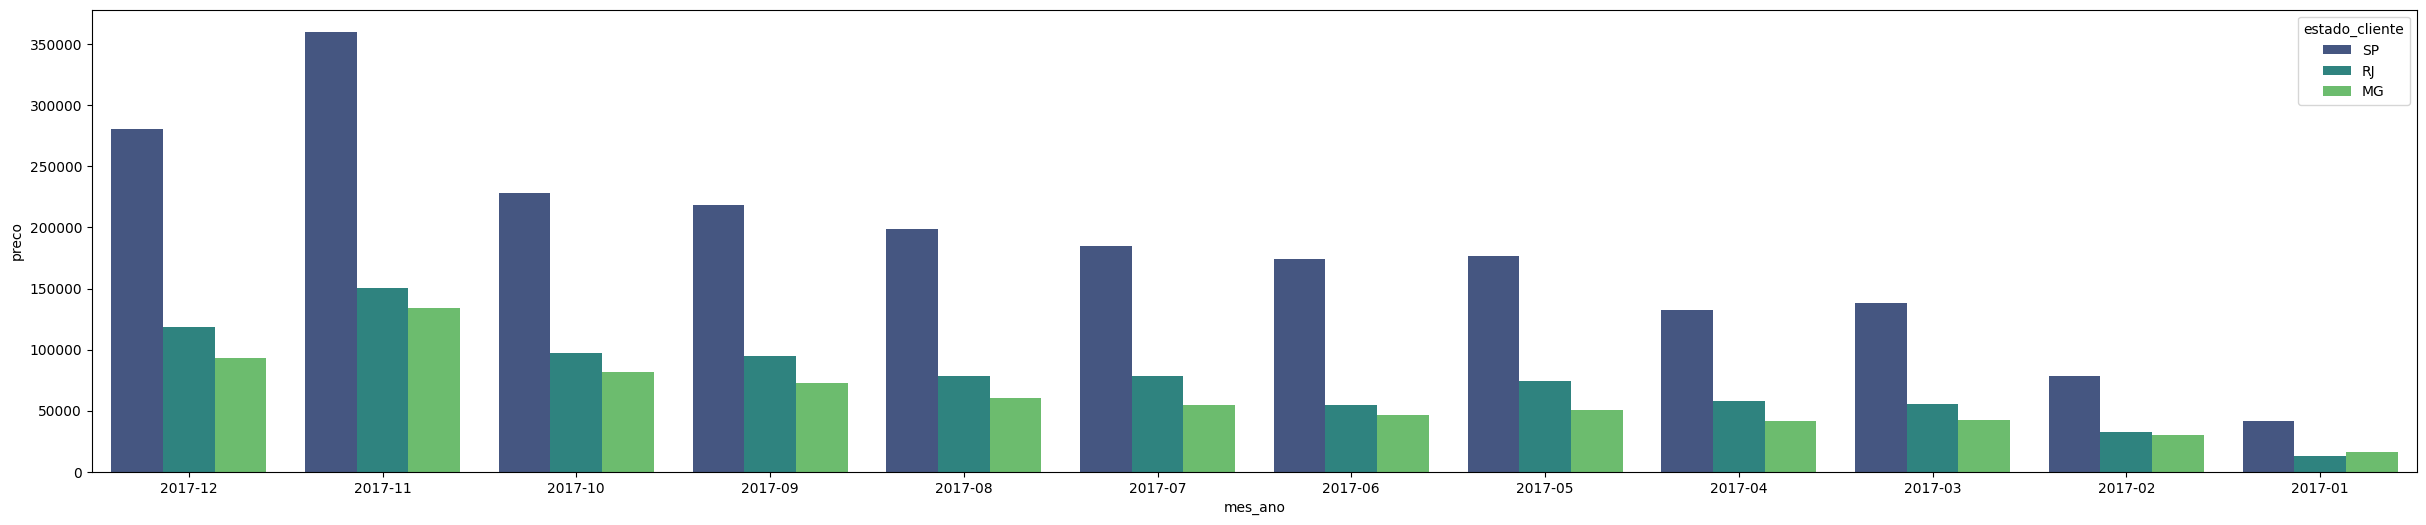

In [ ]:
#Grafico apenas de 2017
top_3_estados_mes_2017 = top_3_estados_mes[top_3_estados_mes['mes_ano'].dt.year == 2017].reset_index(drop=True)
top_3_estados_mes_2017.head()



plt.figure(figsize = (30,6))
sns.barplot(data=top_3_estados_mes_2017, x = 'mes_ano', y = 'preco', hue = 'estado_cliente', palette = 'viridis')
#
#

#plt.figure(figsize = (12,6))
#sns.barplot(data=infeccoes_estado_2023, x = 'uf', y = 'qtd_infeccoes', palette = 'viridis')


In [ ]:
# Verificando a quantidade de clientes

qtde_clientes = dim_cliente['id_cliente_unico'].nunique()
print(qtde_clientes)

96096


In [ ]:
# Verificando os IDs únicos
clientes_unicos = dim_cliente['id_cliente_unico'].unique()
print(clientes_unicos)

['861eff4711a542e4b93843c6dd7febb0' '290c77bc529b7ac935b93aa66c333dc3'
 '060e732b5b29e8181a18229c7b0b2b5e' ... 'e9f50caf99f032f0bf3c55141f019d99'
 '73c2643a0a458b49f58cea58833b192e' '84732c5050c01db9b23e19ba39899398']


In [ ]:
# Atribuindo a quantidade de pedidos a cada Cliente (Id Único)
df_resultado = (
    dim_cliente
    .groupby('id_cliente_unico')['id_cliente']
    .count()
    .reset_index(name='qtde_id_cliente')
)

# Filtrando e trazendo apenas os que possuem mais de um pedido
df_filtrado = df_resultado[df_resultado['qtde_id_cliente'] > 1]

In [ ]:
#Verificando quantos clientes possuem mais de um pedido

qtde_clientes_recompra = len(df_filtrado)
print(qtde_clientes_recompra)


2997


In [ ]:
df_filtrado = dim_reviews[dim_reviews.duplicated(subset='pedido_id', keep=False)]
df_filtrado.head()

,id_avaliacao,pedido_id,nota,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
30,540e7bbb2d06cfb7f85f3a88ba7ac97f,cf73e2cb1f4a9480ed70c154da3d954a,5,NaN,NaN,2018-01-18,2018-01-18 19:12:30
344,a0a641414ff718ca079b3967ef5c2495,169d7e0fd71d624d306f132acd791cbe,5,NaN,NaN,2018-03-04,2018-03-06 20:12:53
498,505a882ba08a689682a4afc6eb4e5965,1c308eca3f339414a92e518e2a2e5ee9,2,NaN,NaN,2017-12-28,2017-12-31 20:25:02
764,c5976a5a98e854fb23d7e03c6754ae60,2002ea16e75277eaa0b5d78632048540,5,NaN,NaN,2017-08-08,2017-08-10 11:11:29
778,62c7722239b976d943ec0d430cfe890e,1d297b4800ed1a3c5b0944d84c01ee99,3,NaN,NaN,2017-10-22,2017-10-31 15:33:32
